#### This notebook reproduces Figure S9 in "Exceeding Human Heat Tolerance: Global Projections for a Warming, Aging World" by Kong et al.

In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
%matplotlib inline
%config InlineBackend.figure_format = "retina"

ERROR 1: PROJ: proj_create_from_database: Open of /home/kong97/.conda/envs/geo_env/share/proj failed


In [2]:
# directory to data; you might want to change it to your own directory
path='../data/'
# read in annual uncompensable heat hours
UHShour=xr.open_dataset(path+'Annual_uncompensable_heat_hours_region_adjustment.nc').hothour
# read in land mask file
landmask=xr.open_dataset(path+'ERA5_land_mask.nc').mask

In [3]:
# create colormap
colors=np.array([[255,255,255],
                 [255.,255.,229.],
                 [255.,247.88888889,192.55555556],
                 [254.22222222,231.44444444,154.55555556],
                 [254.,206.33333333,101.],
                 [254.,172.11111111,57.88888889],
                 [246.,134.77777778,31.66666667],
                 [225.33333333,100.,14.],
                 [192.66666667,70.66666667,2.44444444],
                 [144.5,49.5,4.33333333],
                 [76.5,29.5,7.],
                 [255.,105.,180.]])
cmap=mpl.colors.ListedColormap(colors/255.)

In [4]:
# function to plot each individual panel of the figure
def subplot(data,axis,norm,cmap):
    LON,LAT=np.meshgrid(data.lon.values,data.lat.values)
    g=axis.pcolormesh(LON, LAT,data.where(landmask==0),
                      transform=ccrs.PlateCarree(),
                      cmap=cmap,norm=norm,rasterized=True) 
    axis.coastlines(linewidth=0.5,resolution='50m') # add coastlines
    axis.set_title('')
    axis.set_extent([-169.999,189.999,-60,75]) # set extent of the map to exclude high latitudes
    return g

# function to plot the whole figure
def plot(data):
    fig = plt.figure(figsize=[15,12]) # create figure
    levels=[0,6,18,30,42,84,126,180,360,540,1080,1620] # set levels for color scale
    norm=mpl.colors.BoundaryNorm(levels,ncolors=len(levels),extend='max')
    clabel='Hours' # colorbar label
    
    anno_opts = dict(xy=(0, 1), xycoords='axes fraction',va='baseline', ha='center')
    annots=['a','b','c','d','e','f','g','h','i','j','k','l']
    
    k=0
    for X in [1.5,2,3,4]: # loop over warming levels
        for age in ['young','middle-aged','old']: # loop over age groups
            axis=fig.add_subplot(4,3,k+1,projection=ccrs.Robinson(central_longitude=10))
            g=subplot(data.sel(X=X,age_group=age),axis,norm,cmap)
            axis.annotate(annots[k], **anno_opts,fontsize=16)  
            k+=1
    
    axes=fig.get_axes()        
    anno_opts = dict(xy=(0.5, 1.05), xycoords='axes fraction',va='baseline', ha='center')
    axes[0].annotate('Young', **anno_opts,fontsize=18)
    axes[1].annotate('Middle-aged', **anno_opts,fontsize=18) 
    axes[2].annotate('Elderly', **anno_opts,fontsize=18) 
    
    anno_opts = dict(xy=(-0.05, 0.5), xycoords='axes fraction',va='center', ha='center',rotation=90)
    axes[0].annotate('1.5°C', **anno_opts,fontsize=18)
    axes[3].annotate('2°C', **anno_opts,fontsize=18) 
    axes[6].annotate('3°C', **anno_opts,fontsize=18) 
    axes[9].annotate('4°C', **anno_opts,fontsize=18) 
    
    
    fig.subplots_adjust(bottom=0, left=0,right=1, top=1,hspace=-0.5,wspace=0.05)
    cb=fig.colorbar(g,ax=axes,orientation='horizontal',pad=0.02,shrink=0.75,fraction=.08,aspect=70,ticks=np.array(levels))
    tick_labels=['0','6','18','30','42','84','126','180','360','540','1080','1620']
    cb.set_ticklabels(tick_labels)
    cb.set_label(label=clabel, size=16)
    cb.ax.tick_params(labelsize=14)

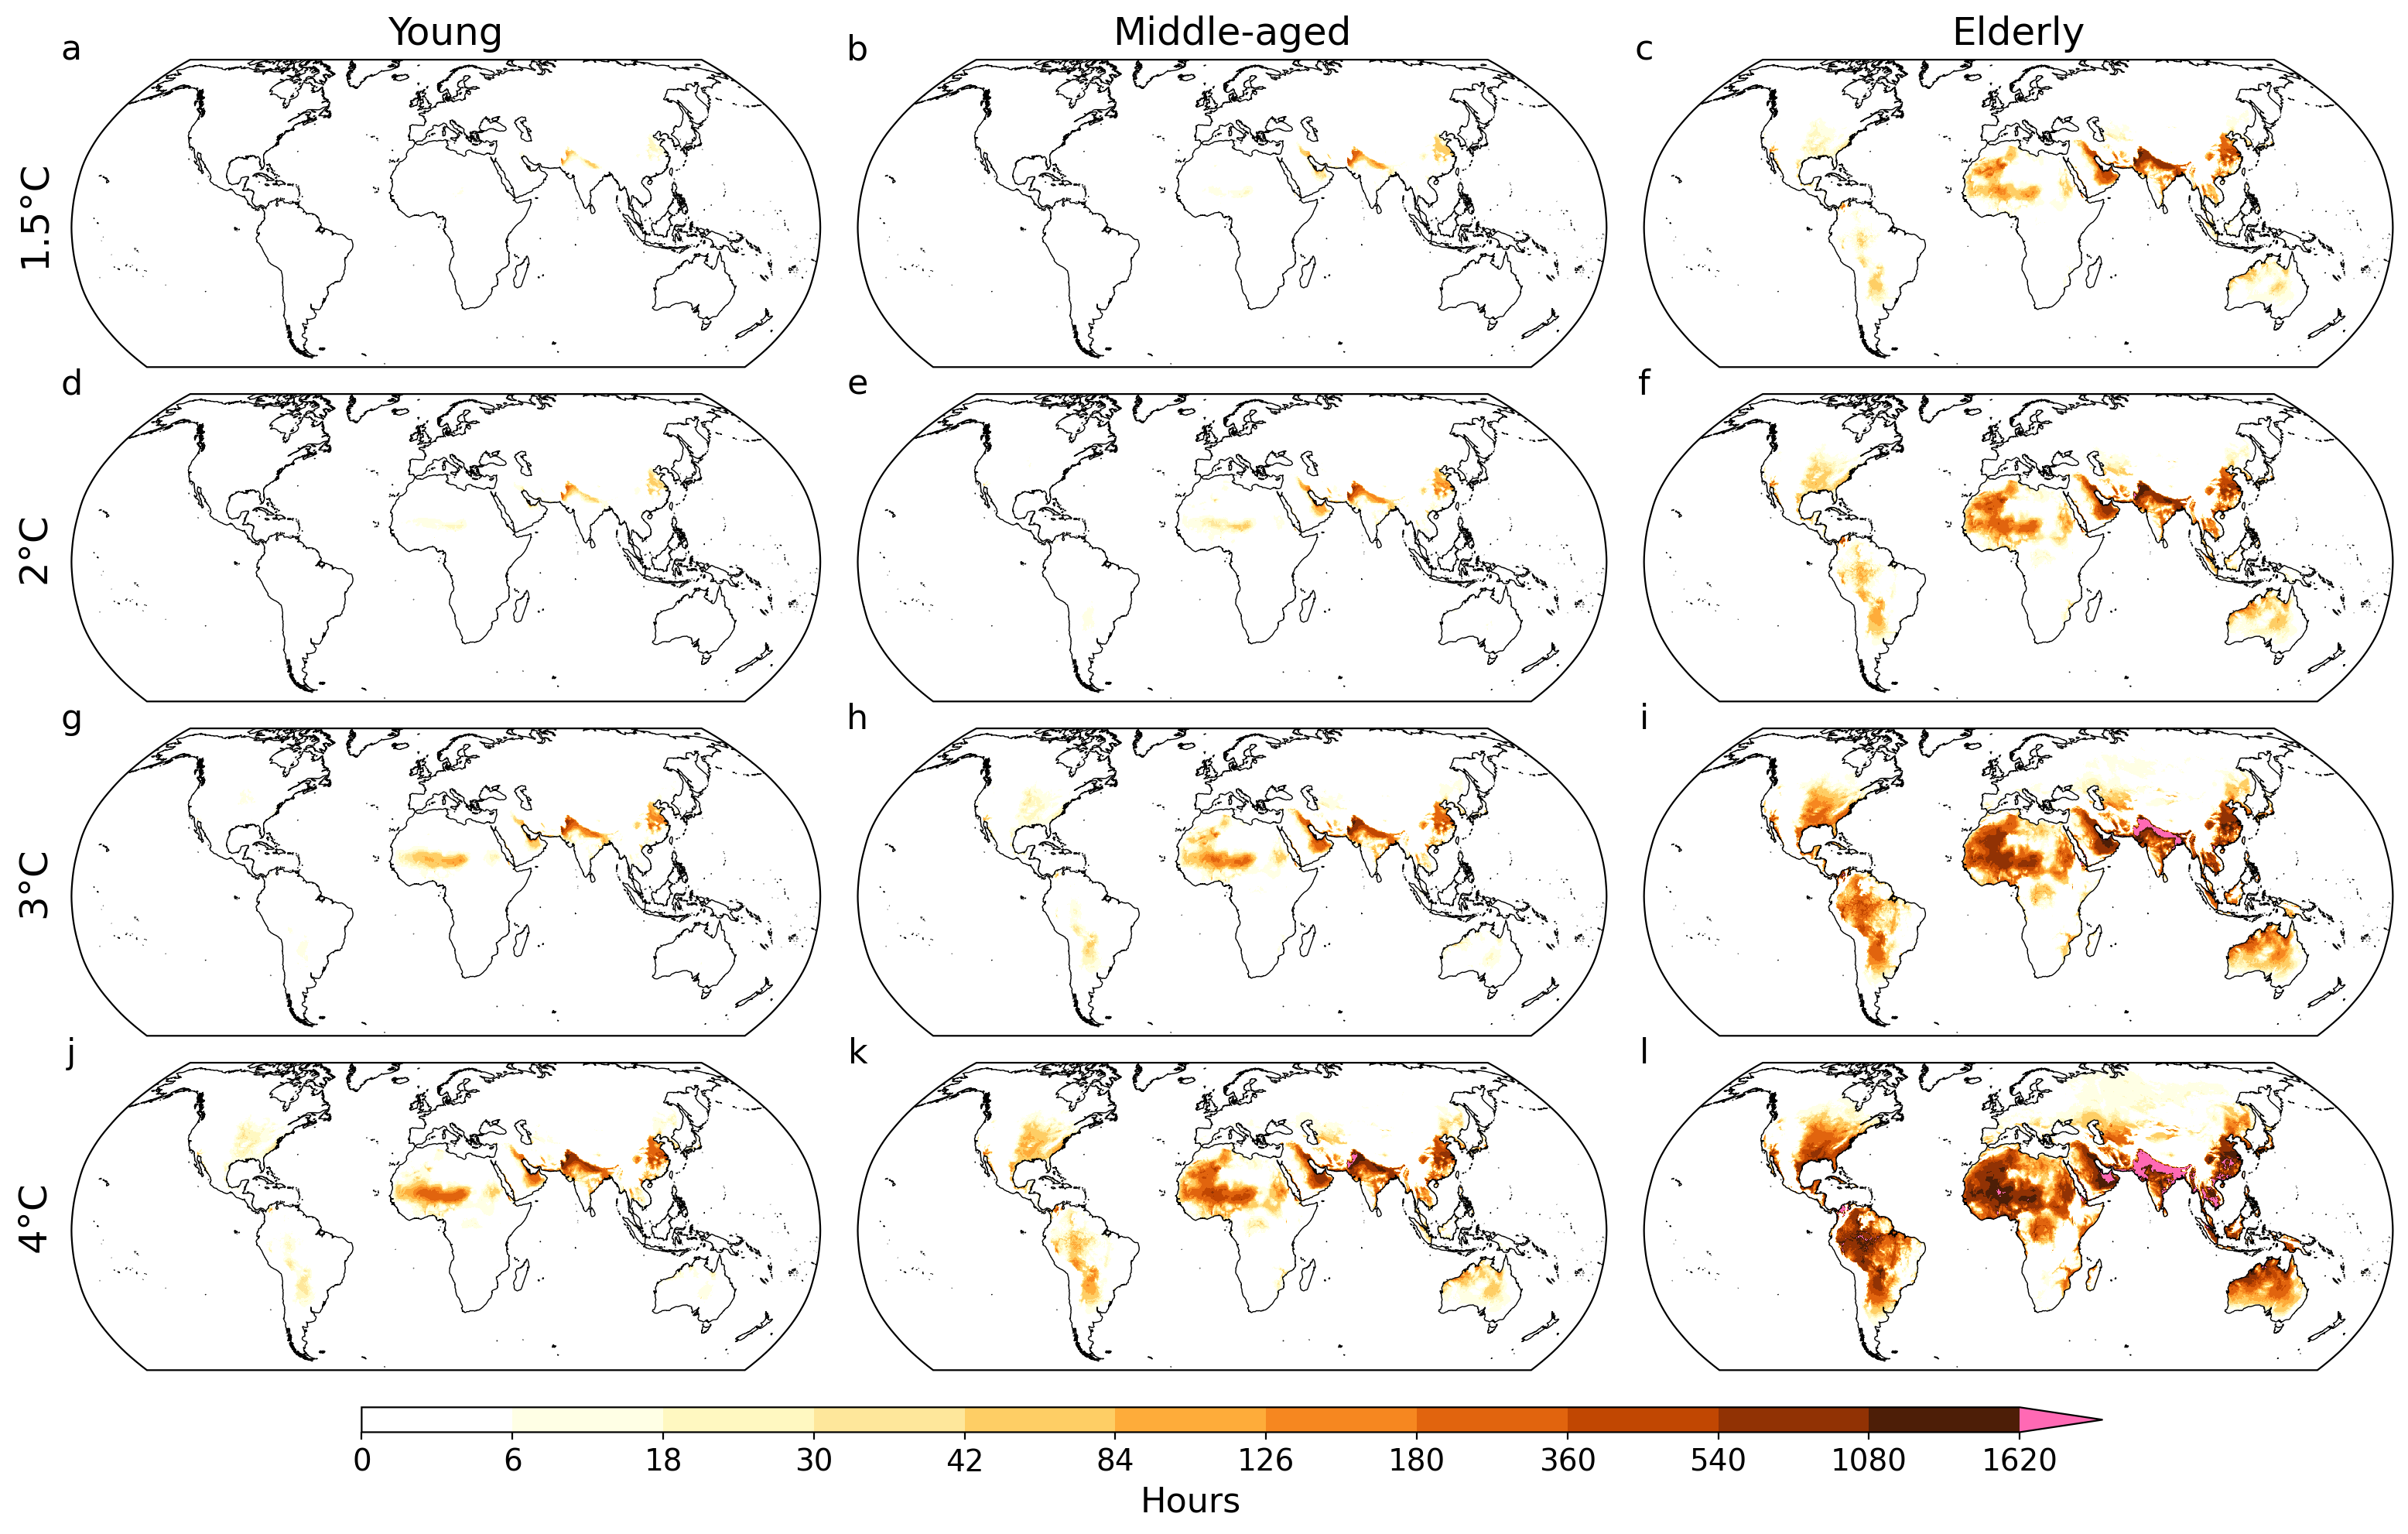

In [5]:
plot(UHShour)

**Fig. S9** Same as Fig. 1 except based on regionally adjusted heat compensability thresholds.